<a href="https://colab.research.google.com/github/zeneanand/IADAI201-1000442-ZENE-SOPHIE-ANAND/blob/main/FA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

for root, dirs, files in os.walk("/content/Coffee_room_02"):
    for file in files:
        if file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            print(os.path.join(root, file))

In [ ]:
zfrom IPython.display import Video

video_path = "/content/Coffee_room_02/Coffee_room_02/video (51).mp4"

Video(video_path, embed=True)

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d tuyenldvn/falldataset-imvia

Dataset URL: https://www.kaggle.com/datasets/tuyenldvn/falldataset-imvia
License(s): unknown
100% 9.37G/9.37G [01:18<00:00, 129MB/s]



In [ ]:
!unzip -o falldataset-imvia.zip

Archive:  falldataset-imvia.zip
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (1).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (10).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (11).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (12).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (13).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (14).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (15).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (16).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (17).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (18).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (19).txt  
  inflating: Coffee_room_01/Coffee_room_01/Annotation_files/video (2).txt  
  inflating: Coffee_room_01/Coffee_room_01/Ann

In [ ]:
ls

Coffee_room_01/        Home_01/       Office/               sample_data/
Coffee_room_02/        Home_02/       pose_landmarker.task
falldataset-imvia.zip  Lecture_room/  README.txt


In [ ]:
# TensorFlow is imported later, in the training cell.
# Loading it before MediaPipe crashes the Colab session.
print("Skipping TensorFlow here so the pose cell can run.")

In [ ]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)


np.random.seed(42)

# Annotation file
annotation_path = "/content/Coffee_room_02/Coffee_room_02/Annotations_files/video (51).txt"

# Read annotations
with open(annotation_path, "r") as f:
    lines = f.readlines()

print("Number of annotation lines:", len(lines))
print("\nFirst 10 lines:")

for line in lines[:10]:
    print(line.strip())

Number of annotation lines: 205

First 10 lines:
76
117
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
5,1,0,0,0,0
6,1,0,0,0,0
7,1,0,0,0,0
8,1,0,0,0,0


In [ ]:
CLASSES = ['fall', 'walking', 'sitting', 'standing', 'normal']
NUM_CLASSES = len(CLASSES)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20


In [ ]:
data_root = '/content'
video_paths = ["/content/Coffee_room_02/Coffee_room_02/video (51).mp4"]
annotation_paths = ["/content/Coffee_room_02/Coffee_room_02/Annotations_files/video (51).txt"]

# List all top-level directories in the data_root
directories = [d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d)) and d not in ['sample_data', '.config']]

for directory in directories:
    # Construct the path to the inner directory (e.g., Coffee_room_01/Coffee_room_01/)
    inner_dir = os.path.join(data_root, directory, directory)

    if not os.path.isdir(inner_dir):
        print(f"Warning: Inner directory not found for {directory}. Skipping.")
        continue

    # Collect video files
    current_video_paths = sorted(glob.glob(os.path.join(inner_dir, '*.avi')))
    video_paths.extend(current_video_paths)

    # Collect annotation files
    annotation_folder = os.path.join(inner_dir, 'Annotation_files')
    if os.path.isdir(annotation_folder):
        current_annotation_paths = sorted(glob.glob(os.path.join(annotation_folder, '*.txt')))
        annotation_paths.extend(current_annotation_paths)
    else:
        print(f"Warning: Annotation folder not found for {directory}. Skipping annotations for this directory.")

print(f"Found {len(video_paths)} video files.")
print(f"Found {len(annotation_paths)} annotation files.")

# Create a DataFrame to store video and annotation paths
# Assuming a 1:1 mapping and consistent naming between videos and annotations
# We'll need to be careful if naming conventions differ (e.g., 'video (1).avi' vs 'video (1).txt')

# Let's try to match them based on their names (excluding extension and parent folder)
matched_data = []

video_base_names = {os.path.basename(p).split('.')[0]: p for p in video_paths}
annotation_base_names = {os.path.basename(p).split('.')[0]: p for p in annotation_paths}

for base_name, video_path in video_base_names.items():
    if base_name in annotation_base_names:
        matched_data.append({
            'video_path': video_path,
            'annotation_path': annotation_base_names[base_name]
        })
    else:
        print(f"Warning: No matching annotation found for video: {video_path}")

df_data = pd.DataFrame(matched_data)
display(df_data.head())
print(f"DataFrame created with {len(df_data)} matched video-annotation pairs.")

Found 34 video files.
Found 109 annotation files.


,video_path,annotation_path
0,/content/Coffee_room_02/Coffee_room_02/video (...,/content/Home_02/Home_02/Annotation_files/vide...
1,/content/Office/Office/video (1).avi,/content/Coffee_room_01/Coffee_room_01/Annotat...
2,/content/Office/Office/video (10).avi,/content/Coffee_room_01/Coffee_room_01/Annotat...
3,/content/Office/Office/video (11).avi,/content/Coffee_room_01/Coffee_room_01/Annotat...
4,/content/Office/Office/video (12).avi,/content/Coffee_room_01/Coffee_room_01/Annotat...


DataFrame created with 34 matched video-annotation pairs.


In [ ]:
def parse_annotation_file(annotation_path, classes_mapping):
    annotations = []
    try:
        with open(annotation_path, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 3:
                    start_frame, end_frame, event_name = parts
                    start_frame = int(start_frame)
                    end_frame = int(end_frame)
                    # Map event name to a numerical class label
                    class_id = classes_mapping.get(event_name.lower(), classes_mapping.get('normal')) # Default to 'normal' if not found
                    annotations.append({
                        'start_frame': start_frame,
                        'end_frame': end_frame,
                        'event_name': event_name.lower(),
                        'class_id': class_id
                    })
    except FileNotFoundError:
        print(f"Annotation file not found: {annotation_path}")
    except Exception as e:
        print(f"Error parsing annotation file {annotation_path}: {e}")
    return annotations

# Create a mapping from class name to integer ID
class_to_id = {cls: i for i, cls in enumerate(CLASSES)}
print("Class to ID mapping:", class_to_id)

# Example of parsing the first annotation file
if not df_data.empty:
    first_annotation_path = df_data.iloc[0]['annotation_path']
    example_annotations = parse_annotation_file(first_annotation_path, class_to_id)
    print(f"\nExample annotations from {os.path.basename(first_annotation_path)}:")
    for ann in example_annotations:
        print(ann)
else:
    print("No data to parse annotation file example.")

Class to ID mapping: {'fall': 0, 'walking': 1, 'sitting': 2, 'standing': 3, 'normal': 4}

Example annotations from video (51).txt:


In [ ]:
# Step 5: read the fall window, draw the body, and collect a small set of frames.
# The txt files only give the fall start frame and the fall end frame.
# Sitting, standing, and walking come from the body position.
# These avi files crash Colab if OpenCV opens them, so ffmpeg saves one jpg first.

!pip -q install mediapipe==0.10.35
!wget -q -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task

import os
import subprocess
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2

print("Libraries loaded", flush=True)

if "CLASSES" not in globals():
    CLASSES = ["fall", "walking", "sitting", "standing", "normal"]
    NUM_CLASSES = len(CLASSES)
    IMG_SIZE = (224, 224)
    class_to_id = {name: i for i, name in enumerate(CLASSES)}

options = vision.PoseLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path="pose_landmarker.task"),
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
)
pose = vision.PoseLandmarker.create_from_options(options)
print("Pose model ready", flush=True)

POSE_LINKS = [
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
    (11, 23), (12, 24), (23, 24),
    (23, 25), (25, 27), (24, 26), (26, 28),
]

def draw_pose(frame, landmarks):
    height, width = frame.shape[:2]
    points = []
    for lm in landmarks:
        x = int(lm.x * width)
        y = int(lm.y * height)
        points.append((x, y))
        cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)
    for a, b in POSE_LINKS:
        if a < len(points) and b < len(points):
            cv2.line(frame, points[a], points[b], (0, 255, 0), 2)

def read_fall_window(annotation_path):
    with open(annotation_path) as f:
        lines = [line.strip() for line in f if line.strip()]
    fall_start = int(lines[0])
    fall_end = int(lines[1])
    return fall_start, fall_end

def label_from_pose(landmarks, frame_number, fall_start, fall_end):
    if fall_start > 0 and fall_start <= frame_number <= fall_end:
        return "fall"
    if landmarks is None:
        return "normal"
    shoulder_y = (landmarks[11].y + landmarks[12].y) / 2
    hip_y = (landmarks[23].y + landmarks[24].y) / 2
    knee_y = (landmarks[25].y + landmarks[26].y) / 2
    ankle_gap = abs(landmarks[27].x - landmarks[28].x)
    torso = hip_y - shoulder_y
    if torso > 0.05 and (knee_y - hip_y) < torso * 0.55:
        return "sitting"
    if ankle_gap > 0.18:
        return "walking"
    return "standing"

def find_pairs(root="/content"):
    videos = {}
    notes = {}
    for dirpath, _, files in os.walk(root):
        if "sample_data" in dirpath:
            continue
        for name in files:
            path = os.path.join(dirpath, name)
            base, ext = os.path.splitext(name)
            ext = ext.lower()
            if ext in (".avi", ".mp4"):
                videos[base] = path
            elif ext == ".txt" and "annotation" in dirpath.lower():
                notes[base] = path
    pairs = []
    for base, video_path in videos.items():
        if base in notes:
            pairs.append((video_path, notes[base]))
    return pairs

def frame_count(video_path):
    result = subprocess.run(
        [
            "ffprobe", "-v", "error",
            "-select_streams", "v:0",
            "-show_entries", "stream=nb_frames",
            "-of", "csv=p=0",
            video_path,
        ],
        capture_output=True,
        text=True,
    )
    text = result.stdout.strip().split("\n")[0]
    if text.isdigit() and int(text) > 1:
        return int(text)
    return 0

def read_frame(video_path, frame_number):
    out_path = "/tmp/one_frame.jpg"
    if os.path.exists(out_path):
        os.remove(out_path)
    subprocess.run(
        [
            "ffmpeg", "-y", "-loglevel", "error",
            "-i", video_path,
            "-vf", "select=eq(n\\,%d)" % (frame_number - 1),
            "-vframes", "1",
            out_path,
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    if not os.path.exists(out_path):
        return None
    return cv2.imread(out_path)

MAX_VIDEOS = 12
pairs = find_pairs()
print("Video and annotation pairs:", len(pairs), flush=True)
if len(pairs) == 0:
    print("No videos found in /content. Run the unzip cell first, then run this cell again.")
else:
    print("Using the first", min(MAX_VIDEOS, len(pairs)), "videos so Colab does not run out of memory.", flush=True)
    images = []
    labels = []
    counts = {name: 0 for name in CLASSES}
    for video_path, ann_path in pairs[:MAX_VIDEOS]:
        print("Reading", os.path.basename(video_path), flush=True)
        fall_start, fall_end = read_fall_window(ann_path)
        total = frame_count(video_path)
        if total <= 1:
            total = max(fall_end + 5, 30)
        picks = [max(1, total // 10), max(1, total // 3)]
        if fall_start > 0 and fall_end >= fall_start:
            picks.append(max(1, (fall_start + fall_end) // 2))
        for frame_number in picks:
            frame = read_frame(video_path, frame_number)
            if frame is None:
                continue
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb))
            result = pose.detect(mp_image)
            landmarks = result.pose_landmarks[0] if result.pose_landmarks else None
            if landmarks:
                draw_pose(frame, landmarks)
            label = label_from_pose(landmarks, frame_number, fall_start, fall_end)
            images.append(cv2.resize(frame, IMG_SIZE))
            labels.append(class_to_id[label])
            counts[label] += 1
        print(os.path.basename(video_path), counts, flush=True)
    X = np.array(images, dtype="float32") / 255.0
    y = np.array(labels)
    print("Frames per class:", counts, flush=True)
    print("X shape:", X.shape, flush=True)
if 'X' in globals() and len(X) > 0:
    np.save('frames_X.npy', X)
    np.save('frames_y.npy', y)
    print('Saved frames_X.npy and frames_y.npy', flush=True)


Libraries loaded
Pose model ready
Video and annotation pairs: 70
Using the first 12 videos so Colab does not run out of memory.
Reading video (5).avi
video (5).avi {'fall': 1, 'walking': 0, 'sitting': 0, 'standing': 2, 'normal': 0}
Reading video (12).avi
video (12).avi {'fall': 3, 'walking': 0, 'sitting': 1, 'standing': 2, 'normal': 0}
Reading video (25).avi
video (25).avi {'fall': 4, 'walking': 0, 'sitting': 2, 'standing': 3, 'normal': 0}
Reading video (17).avi
video (17).avi {'fall': 6, 'walking': 0, 'sitting': 2, 'standing': 4, 'normal': 0}
Reading video (13).avi
video (13).avi {'fall': 7, 'walking': 0, 'sitting': 3, 'standing': 5, 'normal': 0}
Reading video (22).avi
video (22).avi {'fall': 8, 'walking': 0, 'sitting': 4, 'standing': 6, 'normal': 0}
Reading video (6).avi
video (6).avi {'fall': 9, 'walking': 0, 'sitting': 5, 'standing': 7, 'normal': 0}
Reading video (20).avi
video (20).avi {'fall': 10, 'walking': 0, 'sitting': 5, 'standing': 9, 'normal': 0}
Reading video (3).avi
video

Train, validation, test: 25 5 6


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 611ms/step - accuracy: 0.2400 - loss: 2.8210 - val_accuracy: 0.4000 - val_loss: 1.6441
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 498ms/step - accuracy: 0.3200 - loss: 1.9275 - val_accuracy: 0.8000 - val_loss: 0.9772
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step - accuracy: 0.5600 - loss: 1.0899 - val_accuracy: 0.2000 - val_loss: 1.1549
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step - accuracy: 0.5600 - loss: 1.0037 - val_accuracy: 0.2000 - val_loss: 1.1046
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step - accuracy: 0.7600 - loss: 0.8339 - val_accuracy: 0.8000 - val_loss: 0.8335
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 719ms/step - accuracy: 0.8400 - loss: 0.7402 - val_accuracy: 1.0000 - val_loss: 0.5743
Epoch 7/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 408ms/step - accuracy: 0.8400 - loss: 0.4748 - val_accuracy: 0.8000 - val_loss: 0.4217
Epoch 8/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - accuracy: 0.8000 - loss: 0.5082 - val_accuracy: 1.0000 - val_loss: 0.3468


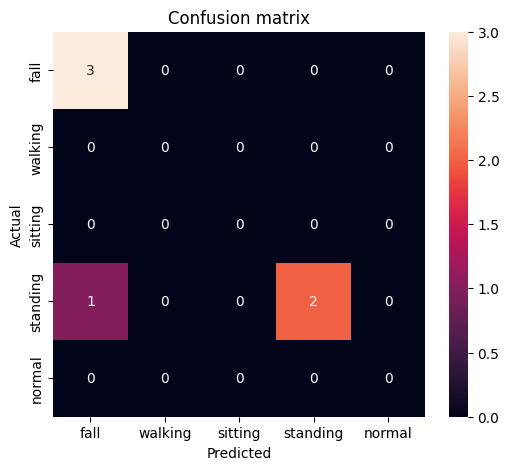

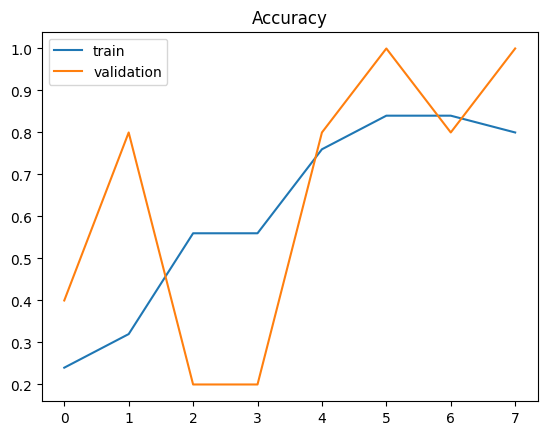

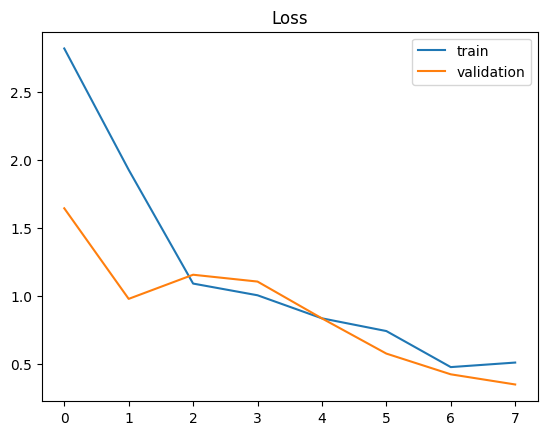

In [ ]:
# Step 5 and 6: split 70/15/15, train a small CNN, then show the marks metrics.
# stratify is left off because some classes have only 1 frame in this small run.

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if "CLASSES" not in globals():
    CLASSES = ["fall", "walking", "sitting", "standing", "normal"]
    NUM_CLASSES = len(CLASSES)
    IMG_SIZE = (224, 224)

if 'X' not in globals():
    X = np.load('frames_X.npy')
    y = np.load('frames_y.npy')
    print('Loaded saved frames', X.shape)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)
print("Train, validation, test:", len(X_train), len(X_val), len(X_test))

model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax"),
])
model.compile(optimizer=Adam(0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=16,
)

probs = model.predict(X_test)
pred = probs.argmax(axis=1)
print(classification_report(
    y_test, pred,
    labels=list(range(len(CLASSES))),
    target_names=CLASSES,
    zero_division=0,
))

cm = confusion_matrix(y_test, pred, labels=list(range(len(CLASSES))))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()
plt.show()


In [ ]:
# Train fall, walking, sitting, and standing from the body position.
# Tilt, knee bend, and foot gap. A sitting person stays sitting.

import math
import os
import subprocess
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

POSE_CLASSES = ["fall", "walking", "sitting", "standing"]
pose_to_id = {name: i for i, name in enumerate(POSE_CLASSES)}

if not os.path.exists("pose_landmarker.task"):
    subprocess.run([
        "wget", "-q", "-O", "pose_landmarker.task",
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task",
    ])

if "pose" not in globals():
    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path="pose_landmarker.task"),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
    )
    pose = vision.PoseLandmarker.create_from_options(options)

def find_pairs(root="/content"):
    videos, notes = {}, {}
    for dirpath, _, files in os.walk(root):
        if "sample_data" in dirpath:
            continue
        for name in files:
            path = os.path.join(dirpath, name)
            base, ext = os.path.splitext(name)
            ext = ext.lower()
            if ext in (".avi", ".mp4"):
                videos[base] = path
            elif ext == ".txt" and "annotation" in dirpath.lower():
                notes[base] = path
    return [(videos[base], notes[base]) for base in videos if base in notes]

def frame_count(video_path):
    result = subprocess.run(
        ["ffprobe", "-v", "error", "-select_streams", "v:0",
         "-show_entries", "stream=nb_frames", "-of", "csv=p=0", video_path],
        capture_output=True, text=True,
    )
    text = result.stdout.strip().split("\n")[0]
    if text.isdigit() and int(text) > 1:
        return int(text)
    return 0

def read_frame(video_path, frame_number):
    out_path = "/tmp/one_frame.jpg"
    if os.path.exists(out_path):
        os.remove(out_path)
    subprocess.run(
        ["ffmpeg", "-y", "-loglevel", "error", "-i", video_path,
         "-vf", "select=eq(n\\,%d)" % (frame_number - 1),
         "-vframes", "1", out_path],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
    if not os.path.exists(out_path):
        return None
    return cv2.imread(out_path)

def read_fall_window(annotation_path):
    with open(annotation_path) as f:
        lines = [line.strip() for line in f if line.strip()]
    if len(lines) >= 2 and lines[0].isdigit() and lines[1].isdigit():
        return int(lines[0]), int(lines[1])
    return 0, 0

def knee_bend(hip, knee, ankle):
    ax, ay = hip.x - knee.x, hip.y - knee.y
    bx, by = ankle.x - knee.x, ankle.y - knee.y
    na = math.hypot(ax, ay)
    nb = math.hypot(bx, by)
    if na * nb == 0:
        return 180.0
    cos = max(-1.0, min(1.0, (ax * bx + ay * by) / (na * nb)))
    return math.degrees(math.acos(cos))

def body_features(landmarks):
    shoulder_x = (landmarks[11].x + landmarks[12].x) / 2
    shoulder_y = (landmarks[11].y + landmarks[12].y) / 2
    hip_x = (landmarks[23].x + landmarks[24].x) / 2
    hip_y = (landmarks[23].y + landmarks[24].y) / 2
    knee_y = (landmarks[25].y + landmarks[26].y) / 2
    ankle_gap = abs(landmarks[27].x - landmarks[28].x)
    dx = hip_x - shoulder_x
    dy = hip_y - shoulder_y
    tilt = abs(math.degrees(math.atan2(dx, dy))) if (dx or dy) else 0.0
    bend = (
        knee_bend(landmarks[23], landmarks[25], landmarks[27])
        + knee_bend(landmarks[24], landmarks[26], landmarks[28])
    ) / 2
    torso = hip_y - shoulder_y
    thigh = knee_y - hip_y
    return [tilt, bend, ankle_gap, torso, thigh]

def body_activity(landmarks):
    tilt, bend, ankle_gap, torso, thigh = body_features(landmarks)
    if tilt > 55 and bend > 110:
        return "fall"
    if bend < 130:
        return "sitting"
    if ankle_gap > 0.14 and bend > 150:
        return "walking"
    return "standing"

MAX_VIDEOS = 40
MAX_PER_CLASS = 30
pairs = find_pairs()
print("Video and annotation pairs:", len(pairs), flush=True)
features, labels = [], []
counts = {name: 0 for name in POSE_CLASSES}
if len(pairs) == 0:
    print("No videos found. Run the unzip cell first.")
else:
    for video_path, ann_path in pairs[:MAX_VIDEOS]:
        if all(counts[name] >= MAX_PER_CLASS for name in POSE_CLASSES):
            break
        fall_start, fall_end = read_fall_window(ann_path)
        total = frame_count(video_path)
        if total <= 1:
            total = max(fall_end + 5, 30)
        picks = [max(1, total // 10), max(1, total // 4), max(1, total // 2)]
        if fall_start > 0 and fall_end >= fall_start:
            picks.append(max(1, (fall_start + fall_end) // 2))
        for frame_number in picks:
            frame = read_frame(video_path, frame_number)
            if frame is None:
                continue
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb))
            result = pose.detect(mp_image)
            if not result.pose_landmarks:
                continue
            label = body_activity(result.pose_landmarks[0])
            if counts[label] >= MAX_PER_CLASS:
                continue
            features.append(body_features(result.pose_landmarks[0]))
            labels.append(pose_to_id[label])
            counts[label] += 1
        print(os.path.basename(video_path), counts, flush=True)

pose_X = np.array(features, dtype="float32")
pose_y = np.array(labels)
print("Pose samples:", counts, pose_X.shape, flush=True)
np.save("pose_X.npy", pose_X)
np.save("pose_y.npy", pose_y)

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_train, X_test, y_train, y_test = train_test_split(
    pose_X, pose_y, test_size=0.30, random_state=42
)
pose_model = Sequential([
    Dense(16, activation="relu", input_shape=(5,)),
    Dense(len(POSE_CLASSES), activation="softmax"),
])
pose_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
pose_model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)
loss, acc = pose_model.evaluate(X_test, y_test, verbose=0)
pose_model.save("pose_model.keras")
print("Pose model accuracy:", round(float(acc), 2), flush=True)
print("Saved pose_model.keras", flush=True)


Video and annotation pairs: 70
video (5).avi {'fall': 1, 'walking': 0, 'sitting': 0, 'standing': 3}
video (12).avi {'fall': 3, 'walking': 0, 'sitting': 0, 'standing': 5}
video (25).avi {'fall': 4, 'walking': 0, 'sitting': 1, 'standing': 7}
video (17).avi {'fall': 7, 'walking': 0, 'sitting': 1, 'standing': 8}
video (13).avi {'fall': 7, 'walking': 0, 'sitting': 2, 'standing': 10}
video (22).avi {'fall': 8, 'walking': 0, 'sitting': 4, 'standing': 11}
video (6).avi {'fall': 8, 'walking': 0, 'sitting': 4, 'standing': 14}
video (20).avi {'fall': 9, 'walking': 0, 'sitting': 4, 'standing': 17}
video (3).avi {'fall': 9, 'walking': 0, 'sitting': 5, 'standing': 20}
video (16).avi {'fall': 10, 'walking': 0, 'sitting': 5, 'standing': 22}
video (18).avi {'fall': 11, 'walking': 0, 'sitting': 5, 'standing': 25}
video (1).avi {'fall': 13, 'walking': 0, 'sitting': 5, 'standing': 26}
video (11).avi {'fall': 14, 'walking': 0, 'sitting': 5, 'standing': 29}
video (26).avi {'fall': 14, 'walking': 0, 'sitting

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pose model accuracy: 0.8
Saved pose_model.keras


In [2]:
# Webcam: one photo, then fall / walking / sitting / standing from the body.

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from google.colab.patches import cv2_imshow
import math
import cv2
import numpy as np

if "POSE_CLASSES" not in globals():
    POSE_CLASSES = ["fall", "walking", "sitting", "standing"]
    pose_to_id = {name: i for i, name in enumerate(POSE_CLASSES)}

if "pose" not in globals():
    import os
    import mediapipe as mp
    from mediapipe.tasks import python
    from mediapipe.tasks.python import vision
    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path="pose_landmarker.task"),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
    )
    pose = vision.PoseLandmarker.create_from_options(options)
else:
    import mediapipe as mp

if "pose_model" not in globals():
    from tensorflow.keras.models import load_model
    pose_model = load_model("pose_model.keras")

def knee_bend(hip, knee, ankle):
    ax, ay = hip.x - knee.x, hip.y - knee.y
    bx, by = ankle.x - knee.x, ankle.y - knee.y
    na = math.hypot(ax, ay)
    nb = math.hypot(bx, by)
    if na * nb == 0:
        return 180.0
    cos = max(-1.0, min(1.0, (ax * bx + ay * by) / (na * nb)))
    return math.degrees(math.acos(cos))

def body_features(landmarks):
    shoulder_x = (landmarks[11].x + landmarks[12].x) / 2
    shoulder_y = (landmarks[11].y + landmarks[12].y) / 2
    hip_x = (landmarks[23].x + landmarks[24].x) / 2
    hip_y = (landmarks[23].y + landmarks[24].y) / 2
    knee_y = (landmarks[25].y + landmarks[26].y) / 2
    ankle_gap = abs(landmarks[27].x - landmarks[28].x)
    dx = hip_x - shoulder_x
    dy = hip_y - shoulder_y
    tilt = abs(math.degrees(math.atan2(dx, dy))) if (dx or dy) else 0.0
    bend = (
        knee_bend(landmarks[23], landmarks[25], landmarks[27])
        + knee_bend(landmarks[24], landmarks[26], landmarks[28])
    ) / 2
    torso = hip_y - shoulder_y
    thigh = knee_y - hip_y
    return [tilt, bend, ankle_gap, torso, thigh]

def body_activity(landmarks):
    tilt, bend, ankle_gap, torso, thigh = body_features(landmarks)
    if tilt > 55 and bend > 110:
        return "fall"
    if bend < 130:
        return "sitting"
    if ankle_gap > 0.14 and bend > 150:
        return "walking"
    return "standing"

def draw_pose(frame, landmarks):
    height, width = frame.shape[:2]
    points = []
    links = [
        (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
        (11, 23), (12, 24), (23, 24),
        (23, 25), (25, 27), (24, 26), (26, 28),
    ]
    for lm in landmarks:
        x = int(lm.x * width)
        y = int(lm.y * height)
        points.append((x, y))
        cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)
    for a, b in links:
        if a < len(points) and b < len(points):
            cv2.line(frame, points[a], points[b], (0, 255, 0), 2)

def take_photo(filename="webcam.jpg", quality=0.8):
    js = Javascript("""
        async function takePhoto(quality) {
          const div = document.createElement("div");
          const capture = document.createElement("button");
          capture.textContent = "Capture";
          div.appendChild(capture);
          const video = document.createElement("video");
          video.style.display = "block";
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
          await new Promise((resolve) => { capture.onclick = resolve; });
          const canvas = document.createElement("canvas");
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext("2d").drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL("image/jpeg", quality);
        }
    """)
    display(js)
    data = eval_js("takePhoto({})" .format(quality))
    binary = b64decode(data.split(",")[1])
    with open(filename, "wb") as f:
        f.write(binary)
    return filename

def predict_activity(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb))
    result = pose.detect(mp_image)
    if not result.pose_landmarks:
        return frame_bgr, "normal", 0.0
    landmarks = result.pose_landmarks[0]
    draw_pose(frame_bgr, landmarks)
    rule_label = body_activity(landmarks)
    feats = np.array([body_features(landmarks)], dtype="float32")
    probs = pose_model.predict(feats, verbose=0)[0]
    model_label = POSE_CLASSES[int(np.argmax(probs))]
    if model_label == rule_label:
        return frame_bgr, model_label, float(probs.max())
    return frame_bgr, rule_label, float(probs[pose_to_id[rule_label]])

filename = take_photo()
frame = cv2.imread(filename)
frame, label, confidence = predict_activity(frame)
print("Activity:", label)
print("Confidence:", round(confidence, 2))
if label == "fall" and confidence >= 0.70:
    print("EMERGENCY: Fall detected. Please check on the person.")
else:
    print("No fall detected.")
cv2_imshow(frame)


ModuleNotFoundError: No module named 'mediapipe'